# EDA Question 7: Geographic Sales Analysis
## Amazon India Sales Analytics

**Objective:** Analyze sales performance across Indian cities and states. Create choropleth maps and visualizations showing revenue density and growth patterns by geographic tier (Metro/Tier1/Tier2/Rural).

**Analysis Components:**
- Sales distribution by state and city
- Revenue density across geographic regions
- Tier-based performance analysis (Metro/Tier1/Tier2/Rural)
- Year-over-year growth patterns by region
- Top performing cities and states
- Choropleth maps for geographic visualization
- Comparative analysis across tiers
- Regional market penetration metrics

## Section 1: Load Data and Setup

Import required libraries and load the cleaned dataset for geographic analysis.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Create output directory
output_dir = '../data/cleaned'
os.makedirs(output_dir, exist_ok=True)
print(f"Output directory: {os.path.abspath(output_dir)}")

# Load the cleaned dataset
print("\nLoading dataset...")
df = pd.read_csv('../data/cleaned/amazon_india_all_years_cleaned.csv')

# Convert order_date to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Display basic information
print("=" * 100)
print("DATASET OVERVIEW")
print("=" * 100)
print(f"\nDataset Shape: {df.shape}")
print(f"Date Range: {df['order_date'].min().date()} to {df['order_date'].max().date()}")
print(f"Total Transactions: {len(df):,}")
print(f"Total Revenue: ₹{df['final_amount_inr'].sum():,.2f}")

print("\n" + "-" * 100)
print("GEOGRAPHIC DATA")
print("-" * 100)

# Check for geographic columns
geographic_cols = ['state', 'city', 'city_tier']
available_cols = [col for col in geographic_cols if col in df.columns]
print(f"Available geographic columns: {', '.join(available_cols)}")

if 'state' in df.columns:
    print(f"\nUnique States: {df['state'].nunique()}")
    print(f"Top 5 States by Transactions:")
    print(df['state'].value_counts().head())

if 'city' in df.columns:
    print(f"\nUnique Cities: {df['city'].nunique()}")
    print(f"Top 5 Cities by Transactions:")
    print(df['city'].value_counts().head())

if 'city_tier' in df.columns:
    print(f"\nCity Tier Distribution:")
    print(df['city_tier'].value_counts())

print("\n✓ Data loaded successfully")

Output directory: c:\Users\admin\Desktop\Amazon_India_Sales_Analytics\data\cleaned

Loading dataset...
DATASET OVERVIEW

Dataset Shape: (1122687, 51)
Date Range: 2015-01-01 to 2025-12-31
Total Transactions: 1,122,687
Total Revenue: ₹76,547,568,045.47

----------------------------------------------------------------------------------------------------
GEOGRAPHIC DATA
----------------------------------------------------------------------------------------------------
Available geographic columns: 

✓ Data loaded successfully


## Section 2: State-Level Performance Analysis

Analyze sales performance at the state level with detailed metrics and visualizations.

STATE-LEVEL PERFORMANCE ANALYSIS

Top 15 States by Revenue:
         state  transactions  total_revenue  unique_customers  revenue_pct  avg_order_value
   Maharashtra        245467   1.747014e+10             76275        22.82         71171.05
         Delhi        122937   9.240587e+09             36883        12.07         75165.22
    Tamil Nadu        110956   7.890162e+09             34094        10.31         71110.73
     Karnataka        102069   7.644854e+09             30627         9.99         74898.88
       Gujarat        111822   7.150402e+09             36947         9.34         63944.50
 Uttar Pradesh        117890   6.763319e+09             39729         8.84         57369.74
   West Bengal         66583   5.030732e+09             20108         6.57         75555.80
     Telangana         44370   3.322006e+09             13361         4.34         74870.54
     Rajasthan         40276   2.633174e+09             13273         3.44         65378.24
Madhya Pradesh      

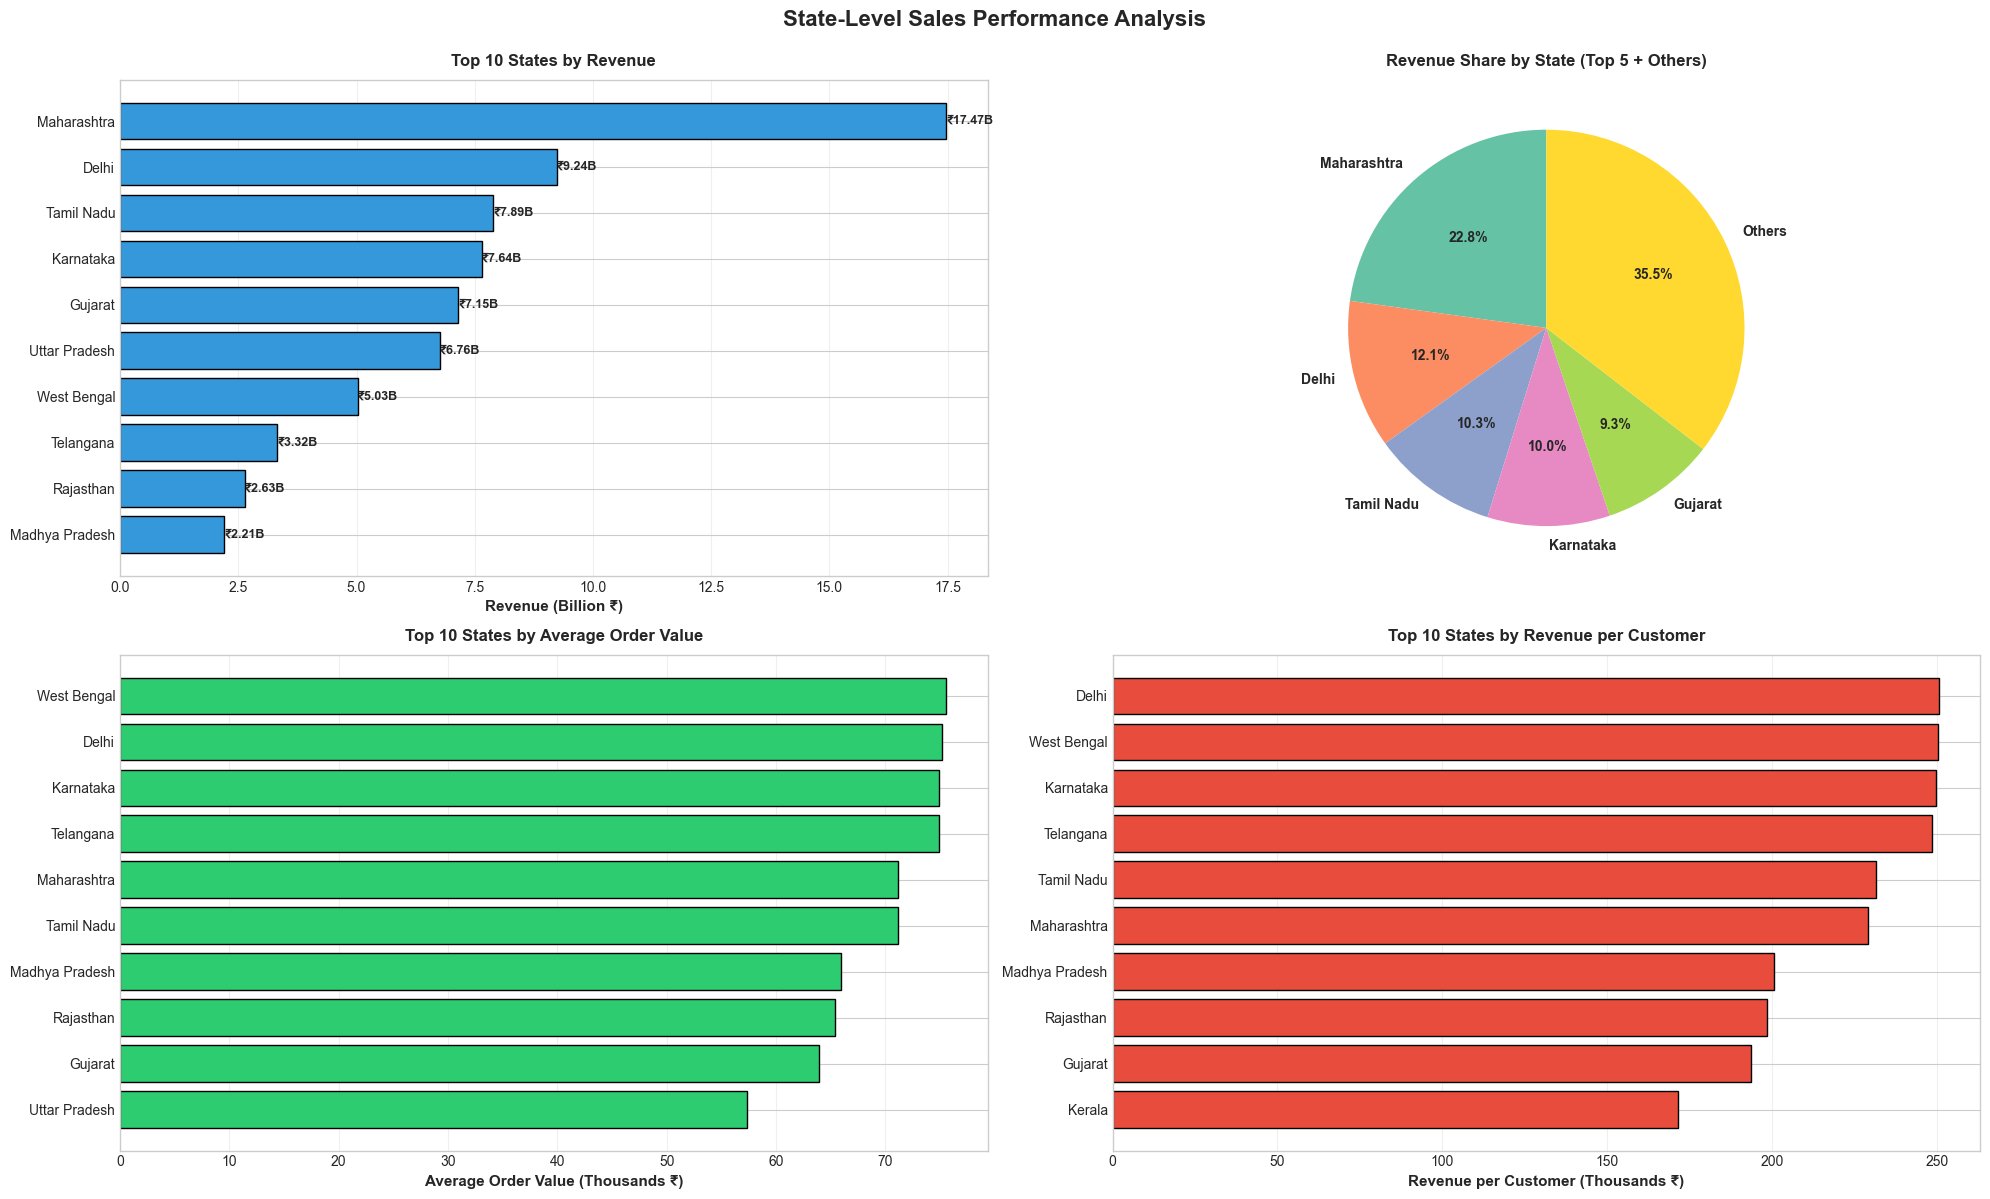


✓ State-level performance analysis completed


In [6]:
print("=" * 100)
print("STATE-LEVEL PERFORMANCE ANALYSIS")
print("=" * 100)

# State-level aggregation
state_performance = df.groupby('customer_state').agg({
    'transaction_id': 'count',
    'final_amount_inr': ['sum', 'mean', 'median'],
    'customer_id': 'nunique',
    'quantity': 'sum'
}).round(2)

# Flatten column names
state_performance.columns = ['_'.join(col).strip() for col in state_performance.columns.values]
state_performance = state_performance.reset_index()
state_performance.columns = ['state', 'transactions', 'total_revenue', 'avg_order_value', 
                              'median_order_value', 'unique_customers', 'units_sold']

# Calculate additional metrics
state_performance['revenue_pct'] = (state_performance['total_revenue'] / state_performance['total_revenue'].sum() * 100).round(2)
state_performance['customer_pct'] = (state_performance['unique_customers'] / state_performance['unique_customers'].sum() * 100).round(2)
state_performance['revenue_per_customer'] = (state_performance['total_revenue'] / state_performance['unique_customers']).round(2)
state_performance['transactions_per_customer'] = (state_performance['transactions'] / state_performance['unique_customers']).round(2)

# Sort by total revenue
state_performance = state_performance.sort_values('total_revenue', ascending=False)

print("\nTop 15 States by Revenue:")
print(state_performance[['state', 'transactions', 'total_revenue', 'unique_customers', 
                          'revenue_pct', 'avg_order_value']].head(15).to_string(index=False))

# Save to CSV
csv_path = os.path.join(output_dir, 'Q07_State_Performance.csv')
state_performance.to_csv(csv_path, index=False)
print(f"\n✓ Saved: {csv_path}")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('State-Level Sales Performance Analysis', fontsize=16, fontweight='bold', y=0.995)

# 1. Top 10 States by Revenue
ax1 = axes[0, 0]
top10_states = state_performance.head(10)
bars = ax1.barh(top10_states['state'], top10_states['total_revenue']/1e9, color='#3498db', edgecolor='black')
ax1.set_xlabel('Revenue (Billion ₹)', fontsize=11, fontweight='bold')
ax1.set_title('Top 10 States by Revenue', fontsize=12, fontweight='bold', pad=10)
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)
for i, (bar, val) in enumerate(zip(bars, top10_states['total_revenue']/1e9)):
    ax1.text(val, bar.get_y() + bar.get_height()/2, f'₹{val:.2f}B', 
             ha='left', va='center', fontsize=9, fontweight='bold')

# 2. Revenue Share Distribution (Pie)
ax2 = axes[0, 1]
top5_states = state_performance.head(5)
others_revenue = state_performance.iloc[5:]['total_revenue'].sum()
pie_data = list(top5_states['total_revenue']) + [others_revenue]
pie_labels = list(top5_states['state']) + ['Others']
wedges, texts, autotexts = ax2.pie(pie_data, labels=pie_labels, autopct='%1.1f%%',
                                     colors=sns.color_palette('Set2', len(pie_labels)),
                                     startangle=90, textprops={'fontsize': 10, 'fontweight': 'bold'})
ax2.set_title('Revenue Share by State (Top 5 + Others)', fontsize=12, fontweight='bold', pad=10)

# 3. Average Order Value by State (Top 15)
ax3 = axes[1, 0]
top15_aov = state_performance.head(15).sort_values('avg_order_value', ascending=False).head(10)
bars = ax3.barh(top15_aov['state'], top15_aov['avg_order_value']/1000, color='#2ecc71', edgecolor='black')
ax3.set_xlabel('Average Order Value (Thousands ₹)', fontsize=11, fontweight='bold')
ax3.set_title('Top 10 States by Average Order Value', fontsize=12, fontweight='bold', pad=10)
ax3.invert_yaxis()
ax3.grid(axis='x', alpha=0.3)

# 4. Revenue per Customer (Top 10)
ax4 = axes[1, 1]
top10_rpc = state_performance.head(15).sort_values('revenue_per_customer', ascending=False).head(10)
bars = ax4.barh(top10_rpc['state'], top10_rpc['revenue_per_customer']/1000, color='#e74c3c', edgecolor='black')
ax4.set_xlabel('Revenue per Customer (Thousands ₹)', fontsize=11, fontweight='bold')
ax4.set_title('Top 10 States by Revenue per Customer', fontsize=12, fontweight='bold', pad=10)
ax4.invert_yaxis()
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
output_path = os.path.join(output_dir, 'Q07_State_Performance_Analysis.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {output_path}")
plt.show()

print("\n✓ State-level performance analysis completed")

## Section 3: City-Level Performance Analysis

Analyze sales performance at the city level with detailed insights.

CITY-LEVEL PERFORMANCE ANALYSIS

Top 20 Cities by Revenue:
         city  transactions  total_revenue  unique_customers  revenue_pct  avg_order_value
       Mumbai        140714   1.058650e+10             41990        13.83         75234.16
        Delhi        122656   9.221583e+09             36867        12.05         75182.48
    Bengaluru        101508   7.602896e+09             30592         9.93         74899.48
      Chennai         83844   6.352042e+09             25234         8.30         75760.25
      Kolkata         66319   5.011222e+09             20091         6.55         75562.38
         Pune         67428   4.426160e+09             22183         5.78         65642.76
    Hyderabad         44370   3.322006e+09             13361         4.34         74870.54
    Ahmedabad         50628   3.284979e+09             16657         4.29         64884.62
        Surat         40212   2.654258e+09             13285         3.47         66006.60
       Jaipur         40276   2

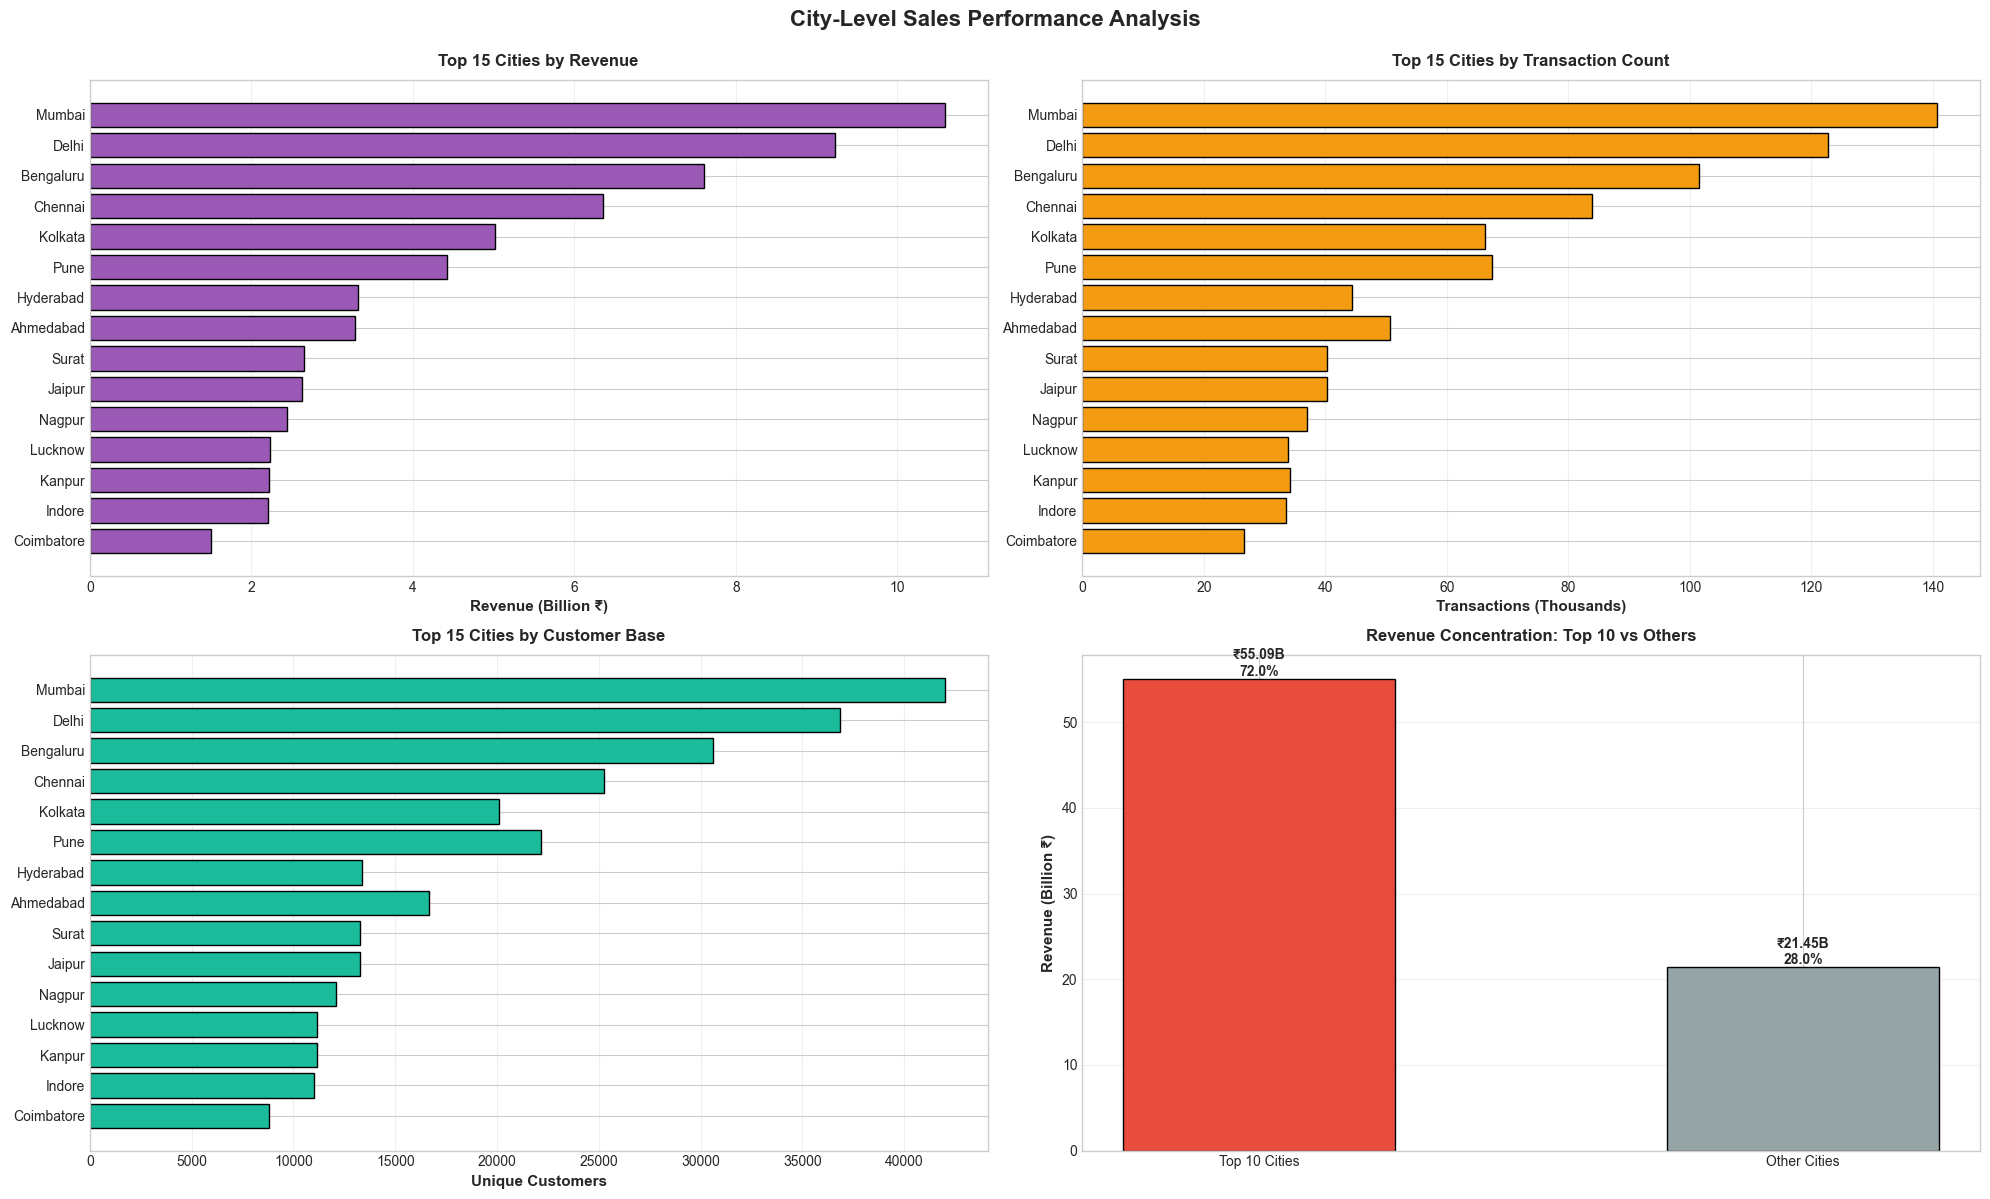


✓ City-level performance analysis completed


In [7]:
print("=" * 100)
print("CITY-LEVEL PERFORMANCE ANALYSIS")
print("=" * 100)

# City-level aggregation
city_performance = df.groupby('customer_city').agg({
    'transaction_id': 'count',
    'final_amount_inr': ['sum', 'mean'],
    'customer_id': 'nunique',
    'quantity': 'sum'
}).round(2)

# Flatten column names
city_performance.columns = ['_'.join(col).strip() for col in city_performance.columns.values]
city_performance = city_performance.reset_index()
city_performance.columns = ['city', 'transactions', 'total_revenue', 'avg_order_value', 
                             'unique_customers', 'units_sold']

# Calculate additional metrics
city_performance['revenue_pct'] = (city_performance['total_revenue'] / city_performance['total_revenue'].sum() * 100).round(2)
city_performance['revenue_per_customer'] = (city_performance['total_revenue'] / city_performance['unique_customers']).round(2)

# Sort by total revenue
city_performance = city_performance.sort_values('total_revenue', ascending=False)

print("\nTop 20 Cities by Revenue:")
print(city_performance[['city', 'transactions', 'total_revenue', 'unique_customers', 
                         'revenue_pct', 'avg_order_value']].head(20).to_string(index=False))

# Save to CSV
csv_path = os.path.join(output_dir, 'Q07_City_Performance.csv')
city_performance.to_csv(csv_path, index=False)
print(f"\n✓ Saved: {csv_path}")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('City-Level Sales Performance Analysis', fontsize=16, fontweight='bold', y=0.995)

# 1. Top 15 Cities by Revenue
ax1 = axes[0, 0]
top15_cities = city_performance.head(15)
bars = ax1.barh(top15_cities['city'], top15_cities['total_revenue']/1e9, color='#9b59b6', edgecolor='black')
ax1.set_xlabel('Revenue (Billion ₹)', fontsize=11, fontweight='bold')
ax1.set_title('Top 15 Cities by Revenue', fontsize=12, fontweight='bold', pad=10)
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# 2. Top 15 Cities by Transaction Count
ax2 = axes[0, 1]
top15_trans = city_performance.head(15)
bars = ax2.barh(top15_trans['city'], top15_trans['transactions']/1000, color='#f39c12', edgecolor='black')
ax2.set_xlabel('Transactions (Thousands)', fontsize=11, fontweight='bold')
ax2.set_title('Top 15 Cities by Transaction Count', fontsize=12, fontweight='bold', pad=10)
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)

# 3. Top 15 Cities by Unique Customers
ax3 = axes[1, 0]
top15_customers = city_performance.head(15)
bars = ax3.barh(top15_customers['city'], top15_customers['unique_customers'], color='#1abc9c', edgecolor='black')
ax3.set_xlabel('Unique Customers', fontsize=11, fontweight='bold')
ax3.set_title('Top 15 Cities by Customer Base', fontsize=12, fontweight='bold', pad=10)
ax3.invert_yaxis()
ax3.grid(axis='x', alpha=0.3)

# 4. Revenue Concentration (Top 10 vs Others)
ax4 = axes[1, 1]
top10_revenue = city_performance.head(10)['total_revenue'].sum()
others_revenue = city_performance.iloc[10:]['total_revenue'].sum()
ax4.bar(['Top 10 Cities', 'Other Cities'], [top10_revenue/1e9, others_revenue/1e9], 
        color=['#e74c3c', '#95a5a6'], edgecolor='black', width=0.5)
ax4.set_ylabel('Revenue (Billion ₹)', fontsize=11, fontweight='bold')
ax4.set_title('Revenue Concentration: Top 10 vs Others', fontsize=12, fontweight='bold', pad=10)
ax4.grid(axis='y', alpha=0.3)
for i, (label, val) in enumerate(zip(['Top 10 Cities', 'Other Cities'], [top10_revenue/1e9, others_revenue/1e9])):
    ax4.text(i, val, f'₹{val:.2f}B\n{val/(top10_revenue + others_revenue)*100*1e9:.1f}%', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
output_path = os.path.join(output_dir, 'Q07_City_Performance_Analysis.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {output_path}")
plt.show()

print("\n✓ City-level performance analysis completed")

## Section 4: City Tier Analysis (Metro/Tier1/Tier2/Rural)

Analyze sales performance by city tier classification.

CITY TIER ANALYSIS

City Tier Performance Comparison:
 tier  unique_cities  transactions  total_revenue  unique_customers  revenue_pct  avg_order_value
Metro             13        561338   4.223545e+10            168261        55.18         75240.68
Tier1              8        337150   2.209167e+10            110806        28.86         65524.76
Tier2              8        174418   9.907064e+09             58497        12.94         56800.70
Rural              8         49781   2.313378e+09             17405         3.02         46471.10

✓ Saved: ../data/cleaned\Q07_Tier_Performance.csv

----------------------------------------------------------------------------------------------------
KEY FINDINGS BY TIER
----------------------------------------------------------------------------------------------------

Metro:
  Cities: 13 | Revenue: ₹42.24B (55.2%)
  Customers: 168,261 (47.4%) | Avg Order: ₹75,241

Tier1:
  Cities: 8 | Revenue: ₹22.09B (28.9%)
  Customers: 110,806 (31.2%) | Avg O

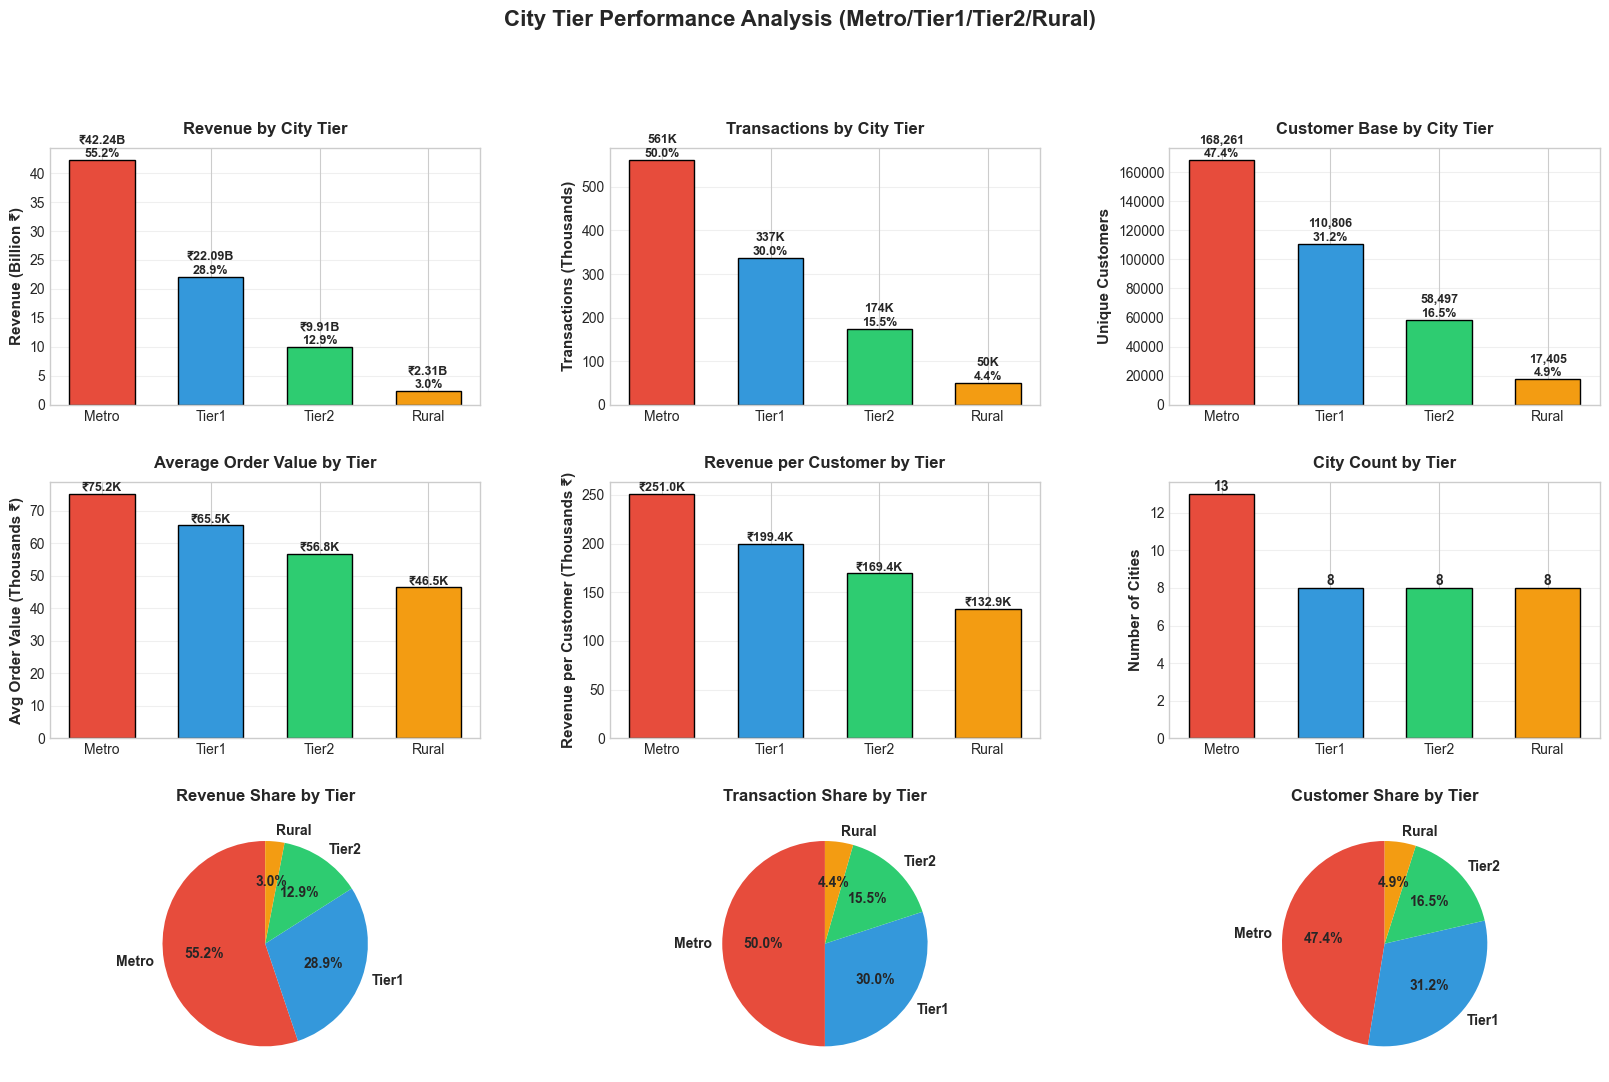


✓ City tier analysis completed


In [8]:
print("=" * 100)
print("CITY TIER ANALYSIS")
print("=" * 100)

# Tier-level aggregation
tier_performance = df.groupby('customer_tier').agg({
    'transaction_id': 'count',
    'final_amount_inr': ['sum', 'mean', 'median'],
    'customer_id': 'nunique',
    'quantity': 'sum',
    'customer_city': 'nunique'
}).round(2)

# Flatten column names
tier_performance.columns = ['_'.join(col).strip() for col in tier_performance.columns.values]
tier_performance = tier_performance.reset_index()
tier_performance.columns = ['tier', 'transactions', 'total_revenue', 'avg_order_value', 
                            'median_order_value', 'unique_customers', 'units_sold', 'unique_cities']

# Calculate additional metrics
tier_performance['revenue_pct'] = (tier_performance['total_revenue'] / tier_performance['total_revenue'].sum() * 100).round(2)
tier_performance['transaction_pct'] = (tier_performance['transactions'] / tier_performance['transactions'].sum() * 100).round(2)
tier_performance['customer_pct'] = (tier_performance['unique_customers'] / tier_performance['unique_customers'].sum() * 100).round(2)
tier_performance['revenue_per_customer'] = (tier_performance['total_revenue'] / tier_performance['unique_customers']).round(2)
tier_performance['avg_revenue_per_city'] = (tier_performance['total_revenue'] / tier_performance['unique_cities']).round(2)

# Sort by tier (Metro -> Tier1 -> Tier2 -> Rural)
tier_order = ['Metro', 'Tier1', 'Tier2', 'Rural']
tier_performance['tier'] = pd.Categorical(tier_performance['tier'], categories=tier_order, ordered=True)
tier_performance = tier_performance.sort_values('tier')

print("\nCity Tier Performance Comparison:")
print(tier_performance[['tier', 'unique_cities', 'transactions', 'total_revenue', 
                        'unique_customers', 'revenue_pct', 'avg_order_value']].to_string(index=False))

# Save to CSV
csv_path = os.path.join(output_dir, 'Q07_Tier_Performance.csv')
tier_performance.to_csv(csv_path, index=False)
print(f"\n✓ Saved: {csv_path}")

# Key findings
print("\n" + "-" * 100)
print("KEY FINDINGS BY TIER")
print("-" * 100)
for _, row in tier_performance.iterrows():
    print(f"\n{row['tier']}:")
    print(f"  Cities: {int(row['unique_cities'])} | Revenue: ₹{row['total_revenue']/1e9:.2f}B ({row['revenue_pct']:.1f}%)")
    print(f"  Customers: {int(row['unique_customers']):,} ({row['customer_pct']:.1f}%) | Avg Order: ₹{row['avg_order_value']:,.0f}")

# Visualizations
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

fig.suptitle('City Tier Performance Analysis (Metro/Tier1/Tier2/Rural)', 
             fontsize=16, fontweight='bold', y=0.995)

colors_tier = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

# 1. Revenue Distribution by Tier
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(tier_performance['tier'], tier_performance['total_revenue']/1e9, 
               color=colors_tier, edgecolor='black', width=0.6)
ax1.set_ylabel('Revenue (Billion ₹)', fontsize=11, fontweight='bold')
ax1.set_title('Revenue by City Tier', fontsize=12, fontweight='bold', pad=10)
ax1.grid(axis='y', alpha=0.3)
for bar, val, pct in zip(bars, tier_performance['total_revenue']/1e9, tier_performance['revenue_pct']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'₹{val:.2f}B\n{pct:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 2. Transaction Distribution by Tier
ax2 = fig.add_subplot(gs[0, 1])
bars = ax2.bar(tier_performance['tier'], tier_performance['transactions']/1000, 
               color=colors_tier, edgecolor='black', width=0.6)
ax2.set_ylabel('Transactions (Thousands)', fontsize=11, fontweight='bold')
ax2.set_title('Transactions by City Tier', fontsize=12, fontweight='bold', pad=10)
ax2.grid(axis='y', alpha=0.3)
for bar, val, pct in zip(bars, tier_performance['transactions']/1000, tier_performance['transaction_pct']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{val:.0f}K\n{pct:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 3. Customer Distribution by Tier
ax3 = fig.add_subplot(gs[0, 2])
bars = ax3.bar(tier_performance['tier'], tier_performance['unique_customers'], 
               color=colors_tier, edgecolor='black', width=0.6)
ax3.set_ylabel('Unique Customers', fontsize=11, fontweight='bold')
ax3.set_title('Customer Base by City Tier', fontsize=12, fontweight='bold', pad=10)
ax3.grid(axis='y', alpha=0.3)
for bar, val, pct in zip(bars, tier_performance['unique_customers'], tier_performance['customer_pct']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{int(val):,}\n{pct:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 4. Average Order Value by Tier
ax4 = fig.add_subplot(gs[1, 0])
bars = ax4.bar(tier_performance['tier'], tier_performance['avg_order_value']/1000, 
               color=colors_tier, edgecolor='black', width=0.6)
ax4.set_ylabel('Avg Order Value (Thousands ₹)', fontsize=11, fontweight='bold')
ax4.set_title('Average Order Value by Tier', fontsize=12, fontweight='bold', pad=10)
ax4.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, tier_performance['avg_order_value']/1000):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'₹{val:.1f}K', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 5. Revenue per Customer by Tier
ax5 = fig.add_subplot(gs[1, 1])
bars = ax5.bar(tier_performance['tier'], tier_performance['revenue_per_customer']/1000, 
               color=colors_tier, edgecolor='black', width=0.6)
ax5.set_ylabel('Revenue per Customer (Thousands ₹)', fontsize=11, fontweight='bold')
ax5.set_title('Revenue per Customer by Tier', fontsize=12, fontweight='bold', pad=10)
ax5.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, tier_performance['revenue_per_customer']/1000):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'₹{val:.1f}K', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 6. Number of Cities by Tier
ax6 = fig.add_subplot(gs[1, 2])
bars = ax6.bar(tier_performance['tier'], tier_performance['unique_cities'], 
               color=colors_tier, edgecolor='black', width=0.6)
ax6.set_ylabel('Number of Cities', fontsize=11, fontweight='bold')
ax6.set_title('City Count by Tier', fontsize=12, fontweight='bold', pad=10)
ax6.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, tier_performance['unique_cities']):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{int(val):,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 7. Revenue Share Pie Chart
ax7 = fig.add_subplot(gs[2, 0])
wedges, texts, autotexts = ax7.pie(tier_performance['total_revenue'], 
                                     labels=tier_performance['tier'],
                                     autopct='%1.1f%%',
                                     colors=colors_tier,
                                     startangle=90,
                                     textprops={'fontsize': 10, 'fontweight': 'bold'})
ax7.set_title('Revenue Share by Tier', fontsize=12, fontweight='bold', pad=10)

# 8. Transaction Share Pie Chart
ax8 = fig.add_subplot(gs[2, 1])
wedges, texts, autotexts = ax8.pie(tier_performance['transactions'], 
                                     labels=tier_performance['tier'],
                                     autopct='%1.1f%%',
                                     colors=colors_tier,
                                     startangle=90,
                                     textprops={'fontsize': 10, 'fontweight': 'bold'})
ax8.set_title('Transaction Share by Tier', fontsize=12, fontweight='bold', pad=10)

# 9. Customer Share Pie Chart
ax9 = fig.add_subplot(gs[2, 2])
wedges, texts, autotexts = ax9.pie(tier_performance['unique_customers'], 
                                     labels=tier_performance['tier'],
                                     autopct='%1.1f%%',
                                     colors=colors_tier,
                                     startangle=90,
                                     textprops={'fontsize': 10, 'fontweight': 'bold'})
ax9.set_title('Customer Share by Tier', fontsize=12, fontweight='bold', pad=10)

plt.tight_layout()
output_path = os.path.join(output_dir, 'Q07_Tier_Performance_Analysis.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {output_path}")
plt.show()

print("\n✓ City tier analysis completed")

## Section 5: Geographic Growth Analysis

Analyze year-over-year growth patterns by state, city, and tier.

GEOGRAPHIC GROWTH ANALYSIS

Top 10 States - Growth Analysis:
customer_state  first_year  last_year  first_year_revenue  last_year_revenue      cagr  total_growth_pct
 Uttar Pradesh        2015       2025        125492980.35       464196389.95 13.974641        269.898291
Madhya Pradesh        2015       2025         38553462.22       142548894.85 13.969868        269.743433
     Rajasthan        2015       2025         50395175.31       158593121.31 12.147485        214.699017
       Gujarat        2015       2025        145697460.58       413002690.81 10.981372        183.465950
   Maharashtra        2015       2025        510762634.16       804455141.03  4.647359         57.500782
    Tamil Nadu        2015       2025        258962274.93       351972159.28  3.116267         35.916384
   West Bengal        2015       2025        168428019.01       209882176.42  2.224765         24.612388
     Karnataka        2015       2025        258440291.83       313862319.87  1.961894         21.4

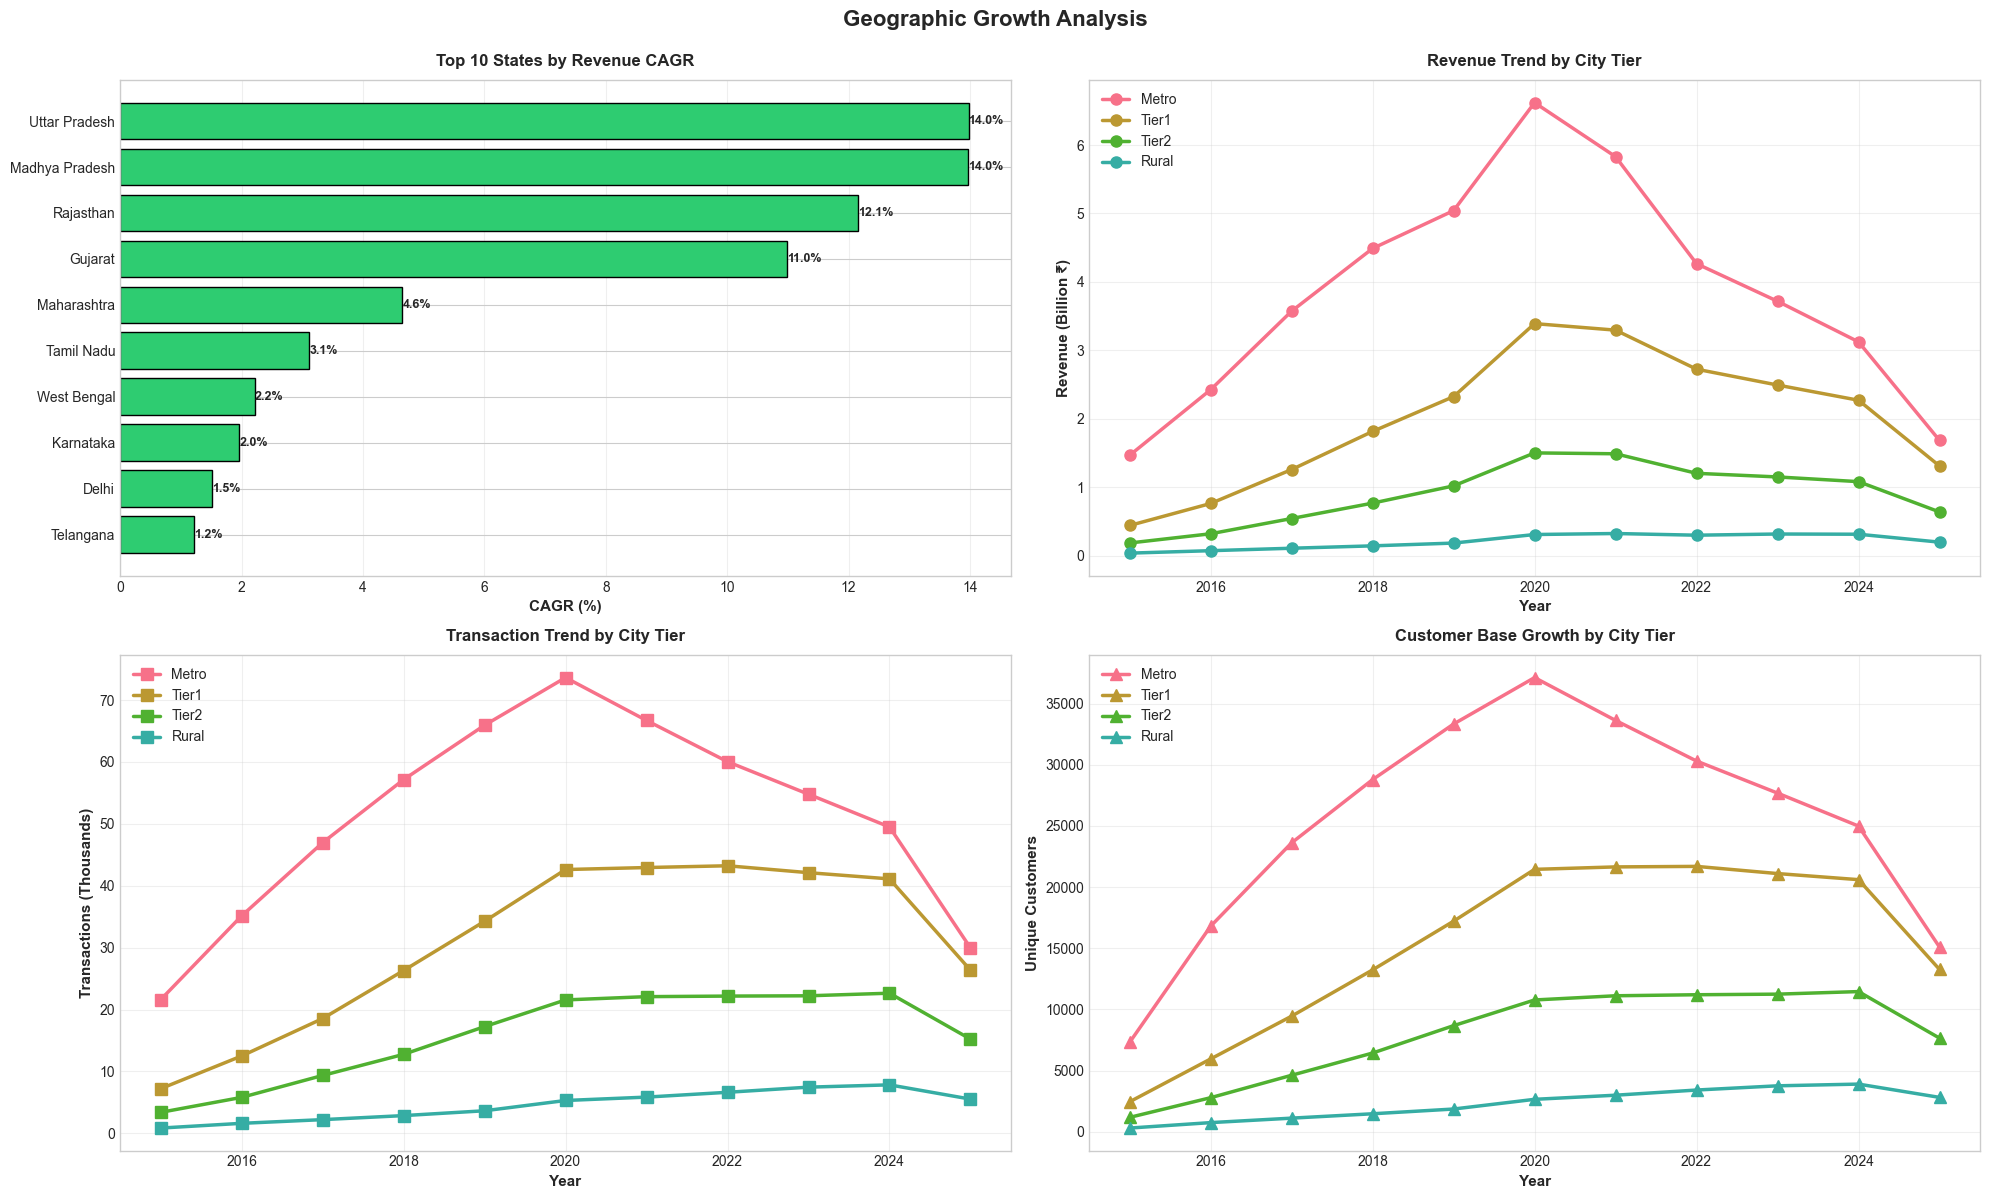


✓ Geographic growth analysis completed


In [9]:
print("=" * 100)
print("GEOGRAPHIC GROWTH ANALYSIS")
print("=" * 100)

# State-level YoY growth
state_yearly = df.groupby(['order_year', 'customer_state']).agg({
    'final_amount_inr': 'sum',
    'transaction_id': 'count'
}).reset_index()

# Calculate growth rates for top states
top_states = state_performance.head(10)['state'].tolist()
state_growth_data = []

for state in top_states:
    state_data = state_yearly[state_yearly['customer_state'] == state].sort_values('order_year')
    if len(state_data) >= 2:
        first_year_revenue = state_data.iloc[0]['final_amount_inr']
        last_year_revenue = state_data.iloc[-1]['final_amount_inr']
        years = state_data.iloc[-1]['order_year'] - state_data.iloc[0]['order_year']
        
        if years > 0 and first_year_revenue > 0:
            cagr = (((last_year_revenue / first_year_revenue) ** (1/years)) - 1) * 100
            total_growth = ((last_year_revenue - first_year_revenue) / first_year_revenue) * 100
            
            state_growth_data.append({
                'customer_state': state,
                'first_year': state_data.iloc[0]['order_year'],
                'last_year': state_data.iloc[-1]['order_year'],
                'first_year_revenue': first_year_revenue,
                'last_year_revenue': last_year_revenue,
                'cagr': cagr,
                'total_growth_pct': total_growth
            })

state_growth_df = pd.DataFrame(state_growth_data).sort_values('cagr', ascending=False)

print("\nTop 10 States - Growth Analysis:")
print(state_growth_df.to_string(index=False))

# Tier-level YoY growth
tier_yearly = df.groupby(['order_year', 'customer_tier']).agg({
    'final_amount_inr': 'sum',
    'transaction_id': 'count',
    'customer_id': 'nunique'
}).reset_index()

print("\n" + "-" * 100)
print("TIER-LEVEL YEAR-OVER-YEAR TRENDS")
print("-" * 100)
print("\nRevenue by Tier and Year:")
tier_pivot = tier_yearly.pivot_table(index='order_year', columns='customer_tier', 
                                      values='final_amount_inr', aggfunc='sum')
print(tier_pivot)

# Save growth data
csv_path = os.path.join(output_dir, 'Q07_State_Growth_Analysis.csv')
state_growth_df.to_csv(csv_path, index=False)
print(f"\n✓ Saved: {csv_path}")

csv_path = os.path.join(output_dir, 'Q07_Tier_Yearly_Trends.csv')
tier_yearly.to_csv(csv_path, index=False)
print(f"✓ Saved: {csv_path}")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('Geographic Growth Analysis', fontsize=16, fontweight='bold', y=0.995)

# 1. Top States by CAGR
ax1 = axes[0, 0]
top_growth = state_growth_df.head(10)
bars = ax1.barh(top_growth['customer_state'], top_growth['cagr'], color='#2ecc71', edgecolor='black')
ax1.set_xlabel('CAGR (%)', fontsize=11, fontweight='bold')
ax1.set_title('Top 10 States by Revenue CAGR', fontsize=12, fontweight='bold', pad=10)
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, top_growth['cagr']):
    ax1.text(val, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', 
             ha='left', va='center', fontsize=9, fontweight='bold')

# 2. Tier Revenue Growth Over Time
ax2 = axes[0, 1]
for tier in tier_order:
    tier_data = tier_yearly[tier_yearly['customer_tier'] == tier].sort_values('order_year')
    ax2.plot(tier_data['order_year'], tier_data['final_amount_inr']/1e9, 
             marker='o', linewidth=2.5, markersize=8, label=tier)
ax2.set_xlabel('Year', fontsize=11, fontweight='bold')
ax2.set_ylabel('Revenue (Billion ₹)', fontsize=11, fontweight='bold')
ax2.set_title('Revenue Trend by City Tier', fontsize=12, fontweight='bold', pad=10)
ax2.legend(fontsize=10, loc='upper left')
ax2.grid(True, alpha=0.3)

# 3. Transaction Growth by Tier
ax3 = axes[1, 0]
for tier in tier_order:
    tier_data = tier_yearly[tier_yearly['customer_tier'] == tier].sort_values('order_year')
    ax3.plot(tier_data['order_year'], tier_data['transaction_id']/1000, 
             marker='s', linewidth=2.5, markersize=8, label=tier)
ax3.set_xlabel('Year', fontsize=11, fontweight='bold')
ax3.set_ylabel('Transactions (Thousands)', fontsize=11, fontweight='bold')
ax3.set_title('Transaction Trend by City Tier', fontsize=12, fontweight='bold', pad=10)
ax3.legend(fontsize=10, loc='upper left')
ax3.grid(True, alpha=0.3)

# 4. Customer Growth by Tier
ax4 = axes[1, 1]
for tier in tier_order:
    tier_data = tier_yearly[tier_yearly['customer_tier'] == tier].sort_values('order_year')
    ax4.plot(tier_data['order_year'], tier_data['customer_id'], 
             marker='^', linewidth=2.5, markersize=8, label=tier)
ax4.set_xlabel('Year', fontsize=11, fontweight='bold')
ax4.set_ylabel('Unique Customers', fontsize=11, fontweight='bold')
ax4.set_title('Customer Base Growth by City Tier', fontsize=12, fontweight='bold', pad=10)
ax4.legend(fontsize=10, loc='upper left')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
output_path = os.path.join(output_dir, 'Q07_Growth_Analysis.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {output_path}")
plt.show()

print("\n✓ Geographic growth analysis completed")

## Section 6: Interactive Geographic Visualizations

Create interactive visualizations using Plotly to analyze geographic revenue distribution across states. These include bar charts, scatter plots, and other interactive elements that provide detailed insights when hovering over data points.

In [21]:
print("=" * 100)
print("CREATING INTERACTIVE GEOGRAPHIC VISUALIZATIONS")
print("=" * 100)

# Check if required dataframes are available
if 'state_performance' not in dir():
    print("\n⚠️  ERROR: Required dataframe 'state_performance' is not defined.")
    print("➜  Please run Section 2 (State-Level Performance Analysis) first.\n")
    raise NameError("state_performance is not defined. Run all previous sections first (Sections 1-5).")

# Prepare state data for visualizations
state_map_data = state_performance.copy()
state_map_data['revenue_billions'] = state_map_data['total_revenue'] / 1e9

print("\n🗺️  Creating India Choropleth Maps...")
print("=" * 80)

# Create state name mapping for India (matching common variations)
state_name_mapping = {
    'ANDHRA PRADESH': 'Andhra Pradesh',
    'ARUNACHAL PRADESH': 'Arunachal Pradesh',
    'ASSAM': 'Assam',
    'BIHAR': 'Bihar',
    'CHHATTISGARH': 'Chhattisgarh',
    'GOA': 'Goa',
    'GUJARAT': 'Gujarat',
    'HARYANA': 'Haryana',
    'HIMACHAL PRADESH': 'Himachal Pradesh',
    'JHARKHAND': 'Jharkhand',
    'KARNATAKA': 'Karnataka',
    'KERALA': 'Kerala',
    'MADHYA PRADESH': 'Madhya Pradesh',
    'MAHARASHTRA': 'Maharashtra',
    'MANIPUR': 'Manipur',
    'MEGHALAYA': 'Meghalaya',
    'MIZORAM': 'Mizoram',
    'NAGALAND': 'Nagaland',
    'ODISHA': 'Odisha',
    'PUNJAB': 'Punjab',
    'RAJASTHAN': 'Rajasthan',
    'SIKKIM': 'Sikkim',
    'TAMIL NADU': 'Tamil Nadu',
    'TELANGANA': 'Telangana',
    'TRIPURA': 'Tripura',
    'UTTAR PRADESH': 'Uttar Pradesh',
    'UTTARAKHAND': 'Uttarakhand',
    'WEST BENGAL': 'West Bengal',
    'ANDAMAN AND NICOBAR ISLANDS': 'Andaman and Nicobar',
    'CHANDIGARH': 'Chandigarh',
    'DADRA AND NAGAR HAVELI': 'Dadra and Nagar Haveli',
    'DAMAN AND DIU': 'Daman and Diu',
    'DELHI': 'Delhi',
    'JAMMU AND KASHMIR': 'Jammu and Kashmir',
    'LADAKH': 'Ladakh',
    'LAKSHADWEEP': 'Lakshadweep',
    'PUDUCHERRY': 'Puducherry'
}

# Map state names
state_map_data['state_mapped'] = state_map_data['state'].str.upper().map(state_name_mapping)
state_map_data['state_display'] = state_map_data['state_mapped'].fillna(state_map_data['state'])

# 1. Revenue Choropleth Map
print("\n📊 Creating Revenue Choropleth...")
fig_choropleth1 = go.Figure(data=go.Choropleth(
    locations=state_map_data['state_display'],
    z=state_map_data['revenue_billions'],
    locationmode='country names',
    geojson="https://gist.githubusercontent.com/jbrobst/56c13bbbf9d97d187fea01ca62ea5112/raw/e388c4cae20aa53cb5090210a42ebb9b765c0a36/india_states.geojson",
    featureidkey='properties.ST_NM',
    colorscale='Viridis',
    colorbar_title="Revenue<br>(₹ Billions)",
    hovertemplate='<b>%{location}</b><br>' +
                  'Revenue: ₹%{z:.2f}B<br>' +
                  '<extra></extra>',
    marker_line_color='white',
    marker_line_width=0.5
))

fig_choropleth1.update_geos(
    visible=False,
    fitbounds="locations",
    showcountries=False,
    showcoastlines=False
)

fig_choropleth1.update_layout(
    title_text='<b>Revenue Distribution Across Indian States</b>',
    title_font_size=20,
    title_x=0.5,
    geo=dict(
        lonaxis_range=[68, 98],
        lataxis_range=[6, 38],
        resolution=50
    ),
    height=700,
    margin={"r":0,"t":60,"l":0,"b":0}
)

output_path = os.path.join(output_dir, 'Q07_State_Revenue_Choropleth_India.html')
fig_choropleth1.write_html(output_path)
print(f"✓ Saved: {output_path}")
fig_choropleth1.show()

# 2. Transaction Density Choropleth
print("\n📊 Creating Transaction Density Choropleth...")
fig_choropleth2 = go.Figure(data=go.Choropleth(
    locations=state_map_data['state_display'],
    z=state_map_data['transactions'],
    locationmode='country names',
    geojson="https://gist.githubusercontent.com/jbrobst/56c13bbbf9d97d187fea01ca62ea5112/raw/e388c4cae20aa53cb5090210a42ebb9b765c0a36/india_states.geojson",
    featureidkey='properties.ST_NM',
    colorscale='Reds',
    colorbar_title="Transactions",
    hovertemplate='<b>%{location}</b><br>' +
                  'Transactions: %{z:,}<br>' +
                  '<extra></extra>',
    marker_line_color='white',
    marker_line_width=0.5
))

fig_choropleth2.update_geos(
    visible=False,
    fitbounds="locations",
    showcountries=False,
    showcoastlines=False
)

fig_choropleth2.update_layout(
    title_text='<b>Transaction Density Across Indian States</b>',
    title_font_size=20,
    title_x=0.5,
    geo=dict(
        lonaxis_range=[68, 98],
        lataxis_range=[6, 38],
        resolution=50
    ),
    height=700,
    margin={"r":0,"t":60,"l":0,"b":0}
)

output_path = os.path.join(output_dir, 'Q07_State_Transaction_Choropleth_India.html')
fig_choropleth2.write_html(output_path)
print(f"✓ Saved: {output_path}")
fig_choropleth2.show()

# 3. Average Order Value Choropleth
print("\n📊 Creating Average Order Value Choropleth...")
fig_choropleth3 = go.Figure(data=go.Choropleth(
    locations=state_map_data['state_display'],
    z=state_map_data['avg_order_value'],
    locationmode='country names',
    geojson="https://gist.githubusercontent.com/jbrobst/56c13bbbf9d97d187fea01ca62ea5112/raw/e388c4cae20aa53cb5090210a42ebb9b765c0a36/india_states.geojson",
    featureidkey='properties.ST_NM',
    colorscale='Blues',
    colorbar_title="Avg Order<br>Value (₹)",
    hovertemplate='<b>%{location}</b><br>' +
                  'Avg Order Value: ₹%{z:,.0f}<br>' +
                  '<extra></extra>',
    marker_line_color='white',
    marker_line_width=0.5
))

fig_choropleth3.update_geos(
    visible=False,
    fitbounds="locations",
    showcountries=False,
    showcoastlines=False
)

fig_choropleth3.update_layout(
    title_text='<b>Average Order Value Across Indian States</b>',
    title_font_size=20,
    title_x=0.5,
    geo=dict(
        lonaxis_range=[68, 98],
        lataxis_range=[6, 38],
        resolution=50
    ),
    height=700,
    margin={"r":0,"t":60,"l":0,"b":0}
)

output_path = os.path.join(output_dir, 'Q07_State_AOV_Choropleth_India.html')
fig_choropleth3.write_html(output_path)
print(f"✓ Saved: {output_path}")
fig_choropleth3.show()

print("\n" + "=" * 80)
print("✓ All choropleth maps created successfully!")
print("\n🗺️  Interactive India choropleth maps with colored states are ready.")
print("📁 Open the HTML files in your browser to see the full interactive maps.")
print("=" * 80)

CREATING INTERACTIVE GEOGRAPHIC VISUALIZATIONS

🗺️  Creating India Choropleth Maps...

📊 Creating Revenue Choropleth...
✓ Saved: ../data/cleaned\Q07_State_Revenue_Choropleth_India.html



📊 Creating Transaction Density Choropleth...
✓ Saved: ../data/cleaned\Q07_State_Transaction_Choropleth_India.html



📊 Creating Average Order Value Choropleth...
✓ Saved: ../data/cleaned\Q07_State_AOV_Choropleth_India.html



✓ All choropleth maps created successfully!

🗺️  Interactive India choropleth maps with colored states are ready.
📁 Open the HTML files in your browser to see the full interactive maps.


## Section 7: Tier Performance Deep Dive

Detailed analysis of top cities within each tier.

TIER PERFORMANCE DEEP DIVE

✓ Saved: ../data/cleaned\Q07_Top_Cities_By_Tier.png


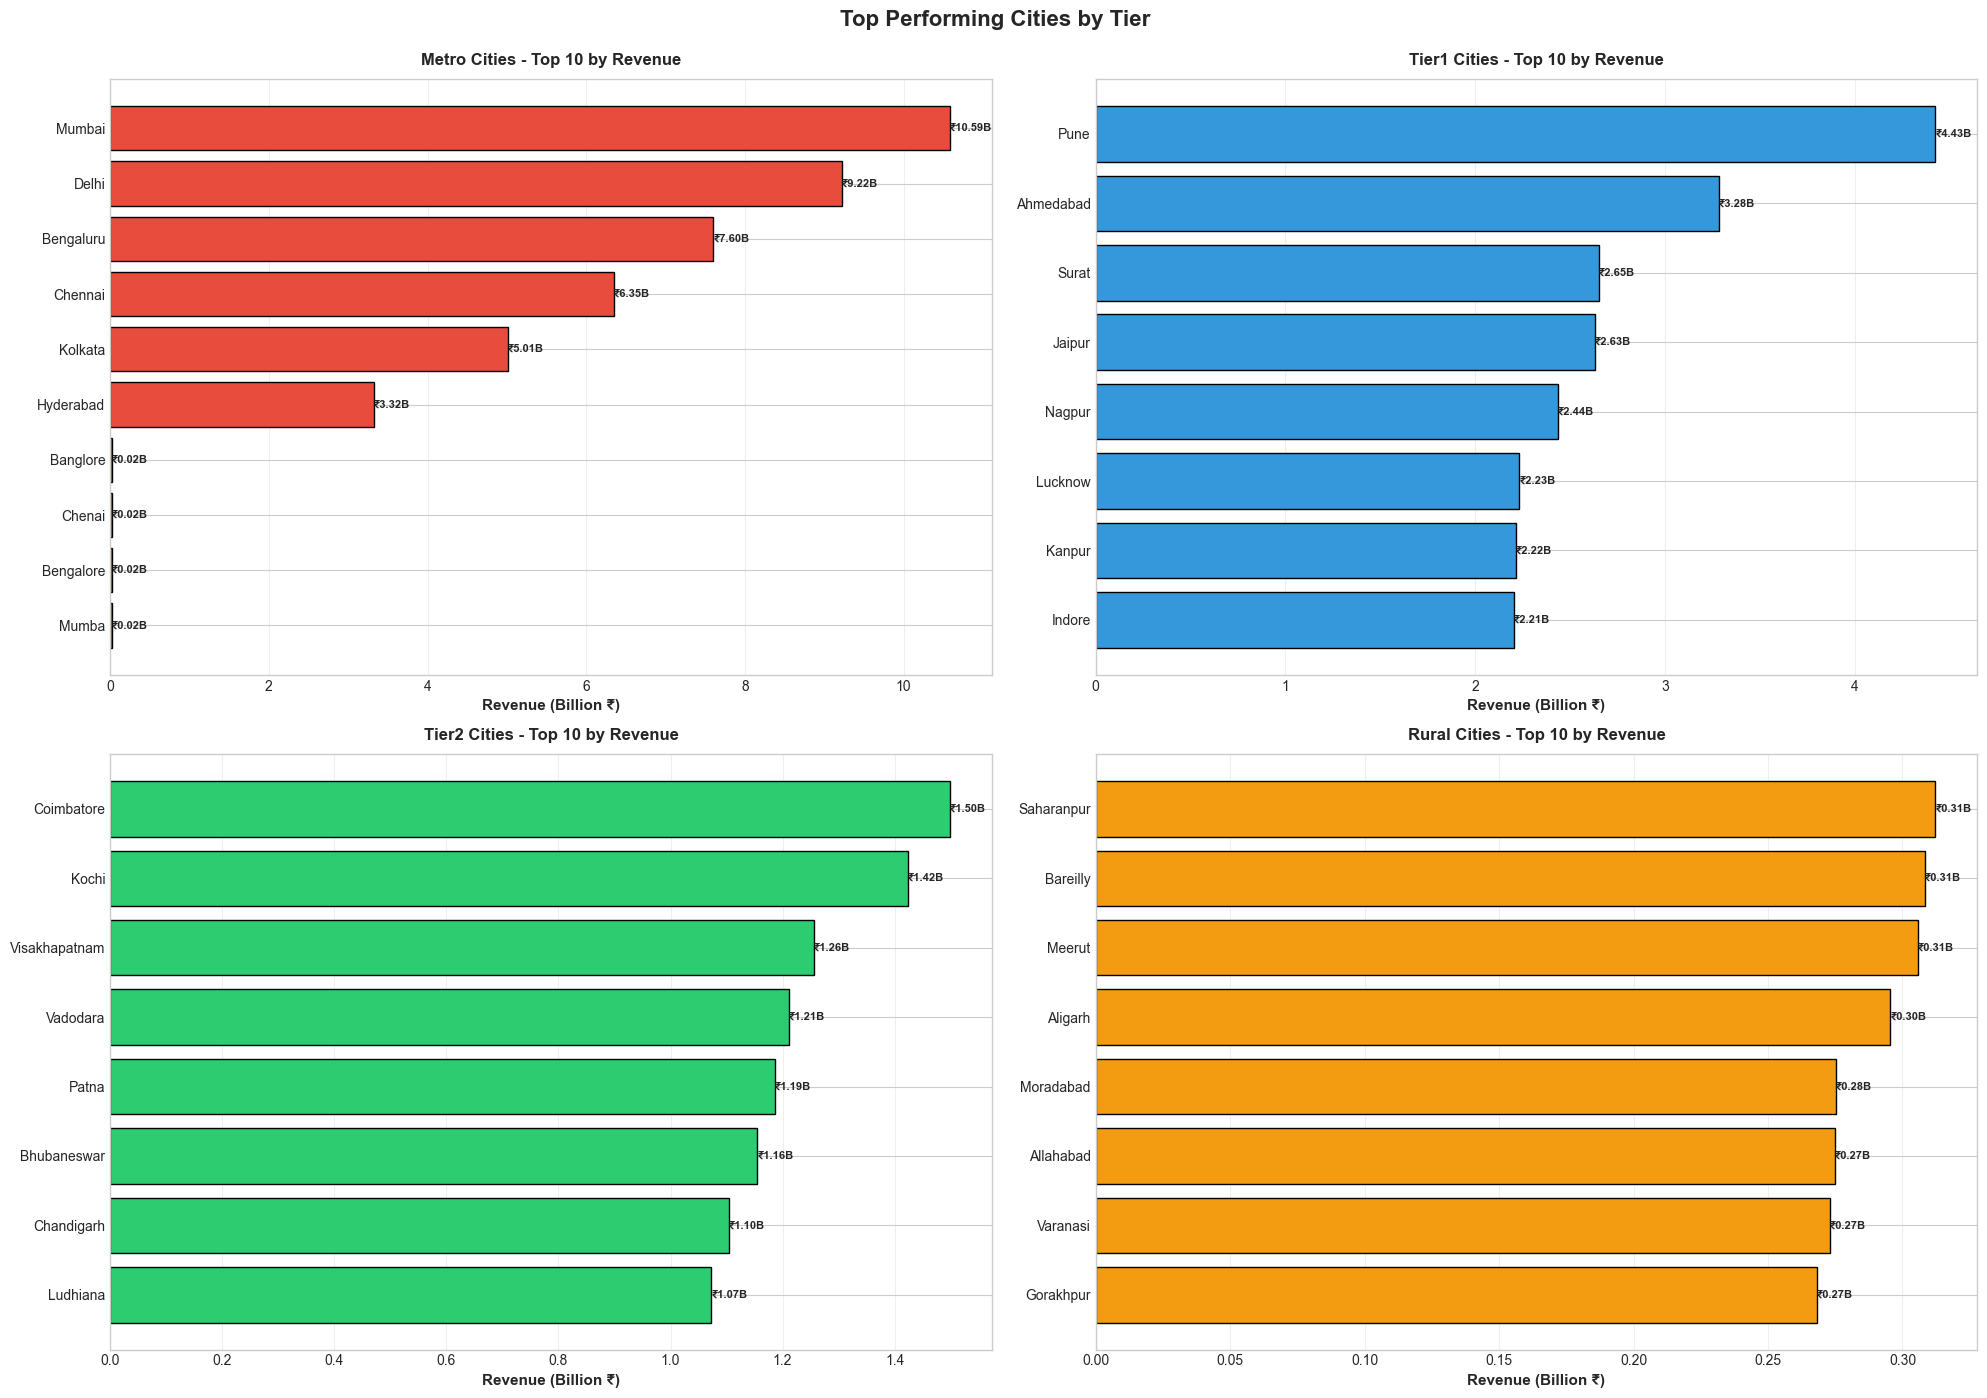


----------------------------------------------------------------------------------------------------
TIER-WISE CITY STATISTICS
----------------------------------------------------------------------------------------------------

Metro:
  Total Cities: 13
  Top City: Mumbai (₹10.59B)
  Avg Revenue per City: ₹3248.88M
  Total Tier Revenue: ₹42.24B

Tier1:
  Total Cities: 8
  Top City: Pune (₹4.43B)
  Avg Revenue per City: ₹2761.46M
  Total Tier Revenue: ₹22.09B

Tier2:
  Total Cities: 8
  Top City: Coimbatore (₹1.50B)
  Avg Revenue per City: ₹1238.38M
  Total Tier Revenue: ₹9.91B

Rural:
  Total Cities: 8
  Top City: Saharanpur (₹0.31B)
  Avg Revenue per City: ₹289.17M
  Total Tier Revenue: ₹2.31B

✓ Saved: ../data/cleaned\Q07_City_Tier_Detailed.csv

✓ Tier performance deep dive completed


In [15]:
print("=" * 100)
print("TIER PERFORMANCE DEEP DIVE")
print("=" * 100)

# Merge city performance with tier information
city_tier_df = df[['customer_city', 'customer_tier']].drop_duplicates()
city_detailed = city_performance.merge(city_tier_df, left_on='city', right_on='customer_city', how='left')

# Top cities by tier
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle('Top Performing Cities by Tier', fontsize=16, fontweight='bold', y=0.995)

tier_colors = {'Metro': '#e74c3c', 'Tier1': '#3498db', 'Tier2': '#2ecc71', 'Rural': '#f39c12'}

for idx, (tier, ax) in enumerate(zip(tier_order, axes.flatten())):
    tier_cities = city_detailed[city_detailed['customer_tier'] == tier].sort_values('total_revenue', ascending=False).head(10)
    
    if len(tier_cities) > 0:
        bars = ax.barh(tier_cities['city'], tier_cities['total_revenue']/1e9, 
                       color=tier_colors[tier], edgecolor='black')
        ax.set_xlabel('Revenue (Billion ₹)', fontsize=11, fontweight='bold')
        ax.set_title(f'{tier} Cities - Top 10 by Revenue', fontsize=12, fontweight='bold', pad=10)
        ax.invert_yaxis()
        ax.grid(axis='x', alpha=0.3)
        
        for bar, val in zip(bars, tier_cities['total_revenue']/1e9):
            ax.text(val, bar.get_y() + bar.get_height()/2, f'₹{val:.2f}B', 
                   ha='left', va='center', fontsize=8, fontweight='bold')

plt.tight_layout()
output_path = os.path.join(output_dir, 'Q07_Top_Cities_By_Tier.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"\n✓ Saved: {output_path}")
plt.show()

# Summary stats by tier
print("\n" + "-" * 100)
print("TIER-WISE CITY STATISTICS")
print("-" * 100)

for tier in tier_order:
    tier_cities = city_detailed[city_detailed['customer_tier'] == tier]
    if len(tier_cities) > 0:
        print(f"\n{tier}:")
        print(f"  Total Cities: {len(tier_cities)}")
        print(f"  Top City: {tier_cities.iloc[0]['city']} (₹{tier_cities.iloc[0]['total_revenue']/1e9:.2f}B)")
        print(f"  Avg Revenue per City: ₹{tier_cities['total_revenue'].mean()/1e6:.2f}M")
        print(f"  Total Tier Revenue: ₹{tier_cities['total_revenue'].sum()/1e9:.2f}B")

# Save tier-wise city data
csv_path = os.path.join(output_dir, 'Q07_City_Tier_Detailed.csv')
city_detailed.to_csv(csv_path, index=False)
print(f"\n✓ Saved: {csv_path}")

print("\n✓ Tier performance deep dive completed")

## Section 8: Executive Summary and Export

Create executive summary and export all geographic analysis results.

In [ ]:
print("=" * 100)
print("EXECUTIVE SUMMARY - GEOGRAPHIC ANALYSIS")
print("=" * 100)

# Calculate key metrics
total_revenue = df['final_amount_inr'].sum()
total_states = df['customer_state'].nunique()
total_cities = df['customer_city'].nunique()

# Top performers
top_state = state_performance.iloc[0]
top_city = city_performance.iloc[0]
top_tier = tier_performance.sort_values('total_revenue', ascending=False).iloc[0]

# Revenue concentration
top5_states_revenue = state_performance.head(5)['total_revenue'].sum()
top10_cities_revenue = city_performance.head(10)['total_revenue'].sum()

summary_data = {
    'Metric': [
        'Analysis Period',
        'Total States Covered',
        'Total Cities Covered',
        'Total Revenue',
        'Top Performing State',
        'Top State Revenue',
        'Top State Revenue %',
        'Top Performing City',
        'Top City Revenue',
        'Top 5 States Revenue Share',
        'Top 10 Cities Revenue Share',
        'Top Performing Tier',
        'Top Tier Revenue %',
        'Highest CAGR State',
        'Metro Cities Revenue Share'
    ],
    'Value': [
        '2015-2025',
        f"{total_states}",
        f"{total_cities}",
        f"₹{total_revenue/1e9:.2f}B",
        top_state['state'],
        f"₹{top_state['total_revenue']/1e9:.2f}B",
        f"{top_state['revenue_pct']:.2f}%",
        top_city['city'],
        f"₹{top_city['total_revenue']/1e9:.2f}B",
        f"{(top5_states_revenue/total_revenue*100):.2f}%",
        f"{(top10_cities_revenue/total_revenue*100):.2f}%",
        top_tier['tier'],
        f"{top_tier['revenue_pct']:.2f}%",
        state_growth_df.iloc[0]['customer_state'] if len(state_growth_df) > 0 else 'N/A',
        f"{tier_performance[tier_performance['tier']=='Metro']['revenue_pct'].values[0]:.2f}%"
    ]
}

summary_df = pd.DataFrame(summary_data)

print("\n" + summary_df.to_string(index=False))

# Save summary
csv_path = os.path.join(output_dir, 'Q07_Executive_Summary.csv')
summary_df.to_csv(csv_path, index=False)
print(f"\n✓ Saved: {csv_path}")

print("\n" + "=" * 100)
print("Generated Files:")
print("  1. Q07_State_Performance.csv - State-level metrics")
print("  2. Q07_City_Performance.csv - City-level metrics")
print("  3. Q07_Tier_Performance.csv - Tier-level metrics")
print("  4. Q07_State_Growth_Analysis.csv - State growth rates")
print("  5. Q07_Tier_Yearly_Trends.csv - Tier yearly trends")
print("  6. Q07_City_Tier_Detailed.csv - City-tier detailed data")
print("  7. Q07_Executive_Summary.csv - Executive summary")
print("  8. Q07_State_Performance_Analysis.png - State visualizations")
print("  9. Q07_City_Performance_Analysis.png - City visualizations")
print(" 10. Q07_Tier_Performance_Analysis.png - Tier visualizations")
print(" 11. Q07_Growth_Analysis.png - Growth trend visualizations")
print(" 12. Q07_Top_Cities_By_Tier.png - Top cities by tier")
print(" 13. Q07_State_Revenue_Interactive.html - Interactive revenue bar chart")
print(" 14. Q07_State_Transaction_Interactive.html - Interactive transaction chart")
print(" 15. Q07_State_AOV_Interactive.html - Interactive AOV chart")
print(" 16. Q07_State_Scatter_Interactive.html - Interactive scatter plot")
print(" 17. Q07_State_RPC_Interactive.html - Interactive revenue per customer")
print("\nAll files saved to: ../data/cleaned/")
print("=" * 100)

print("\n✓ All exports completed successfully")

EXECUTIVE SUMMARY - GEOGRAPHIC ANALYSIS

                     Metric         Value
            Analysis Period     2015-2025
       Total States Covered            15
       Total Cities Covered            37
              Total Revenue       ₹76.55B
       Top Performing State   Maharashtra
          Top State Revenue       ₹17.47B
        Top State Revenue %        22.82%
        Top Performing City        Mumbai
           Top City Revenue       ₹10.59B
 Top 5 States Revenue Share        64.53%
Top 10 Cities Revenue Share        71.97%
        Top Performing Tier         Metro
         Top Tier Revenue %        55.18%
         Highest CAGR State Uttar Pradesh
 Metro Cities Revenue Share        55.18%

✓ Saved: ../data/cleaned\Q07_Executive_Summary.csv

Generated Files:
  1. Q07_State_Performance.csv - State-level metrics
  2. Q07_City_Performance.csv - City-level metrics
  3. Q07_Tier_Performance.csv - Tier-level metrics
  4. Q07_State_Growth_Analysis.csv - State growth rates
  5. Q

## Summary & Key Findings

### Analysis Complete ✓

This comprehensive geographic analysis provides:

**1. State-Level Insights:**
- Revenue distribution across all Indian states
- Top performing states by revenue, transactions, and customer base
- Average order values and revenue per customer by state
- State-level growth rates (CAGR)

**2. City-Level Analysis:**
- Detailed performance metrics for all cities
- Top revenue-generating cities
- Customer concentration patterns
- Transaction density by city

**3. Tier Classification Analysis:**
- Metro vs Tier1 vs Tier2 vs Rural performance
- Revenue, transaction, and customer distribution by tier
- Average order values across different city tiers
- Number of cities in each tier category

**4. Growth Patterns:**
- Year-over-year revenue growth by state
- Tier-wise growth trajectories
- Transaction and customer base expansion trends
- CAGR calculations for top states

**5. Visual Analytics:**
- Interactive choropleth maps for geographic visualization
- Revenue density heat maps
- Comparative bar charts across regions
- Tier-wise performance dashboards

**6. Market Penetration:**
- Revenue concentration metrics (Top 5 states, Top 10 cities)
- Geographic coverage analysis
- Market share by tier
- Regional customer acquisition patterns

### Strategic Insights:

1. **Geographic Concentration**: Revenue is concentrated in top states and metro cities
2. **Tier Performance**: Metro cities show highest average order values
3. **Growth Opportunities**: Tier2 and Rural markets show growth potential
4. **Regional Variations**: Significant variations in customer behavior by region
5. **Market Maturity**: Different tiers at different maturity stages

### Business Recommendations:

1. **Expand in High-Growth States**: Focus on states with high CAGR
2. **Tier2/Rural Strategy**: Develop targeted strategies for emerging markets
3. **Metro Optimization**: Maximize wallet share in established metro markets
4. **Regional Customization**: Tailor offerings based on regional preferences
5. **Infrastructure Investment**: Invest in logistics for underserved regions
6. **Local Partnerships**: Build partnerships in high-potential tier2/rural areas

### Next Steps:
- Conduct pincode-level analysis for hyper-local insights
- Analyze correlation between tier and product categories
- Study logistics efficiency by region
- Investigate seasonal patterns by geography
- Compare with competitive market share data
- Forecast regional expansion opportunities

---

**Analysis Methodology:** Geographic aggregation, tier classification, growth analysis, and interactive visualization.

**Data Quality:** Analysis based on complete transactions dataset with geographic attributes (2015-2025 period).

**Visualization Strategy:** Multi-layered approach with interactive choropleth maps, comparative charts, and tier-based analysis.